# Morph2REP Wavelet Estrous Aberration Pipeline  
## Auto-QC Thresholding + Per-Replicate PCA + Gaussian Mixture + Monte Carlo

This notebook is the “full pipeline” version you asked for:

### Goals
1) **Automatically quality-control (QC)** animal-days using a **data-driven threshold**, so Rep/Dose groups don’t need the same cutoff.  
2) Build wavelet-only daily features and run analysis **per replicate** (and optionally per dose group).  
3) Produce:
- **PCA** (explained variance + loadings)  
- **Gaussian Mixture Model (GMM)** “aberrant state probability”  
- **Handling confound enrichment** (event±1 vs normal)  
- **Monte Carlo null test** for ~4-day cyclicity in `p_aberrant`  

### Important note on “ideal threshold”
There is no perfect “true” threshold without ground truth labels. What we can do robustly is:
- **Detect recording/tracking failures** using `minutes_with_any_bout` (better than locomotion for dose groups).
- Choose thresholds by **separating a low-coverage mode from a normal-coverage mode** using a mixture model (GMM + BIC).
- Provide sensitivity checks and report how many days were removed.

This notebook uses `minutes_with_any_bout` as the QC anchor by default, and can also apply a **relative per-animal coverage ratio** filter.

In [1]:

# =============================================================================
# 0) Imports
# =============================================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import duckdb
from datetime import datetime

from scipy.signal import cwt, morlet2
from scipy.stats import mannwhitneyu

from sklearn.decomposition import PCA
from sklearn.mixture import GaussianMixture

import warnings
warnings.filterwarnings("ignore")

plt.rcParams["figure.dpi"] = 140
plt.rcParams["font.size"] = 10

print("Imports ready.")

Imports ready.


---
## 1) Configuration

### You can run:
- **Vehicle only** (default config below), OR
- multiple dose groups by adding cage IDs to `GROUPS`.

Each group has `Rep1` and `Rep2` entries with:
- cage IDs
- date range
- valid day range (exclude partial day 1)
- event timestamps (dose 1, cage change, dose 2)

**If you add dose cages**, keep the correct dates/events for those replicates.

In [2]:

# =============================================================================
# Constants + wavelet periods
# =============================================================================
MINUTES_PER_DAY = 1440
PERIODS_MINUTES = np.logspace(np.log10(60), np.log10(39 * 60), 50)  # 1h..39h
S3_BASE = "s3://jax-envision-public-data/study_1001/2025v3.3/tabular"

# =============================================================================
# GROUP CONFIG
# Fill dose cages later if you want (dose5, dose25).
# The pipeline loops: for group in GROUPS, for rep in Rep1/Rep2.
# =============================================================================
GROUPS = {
    "vehicle": {
        "Rep1": {
            "cages": [4918, 4922, 4923],
            "analysis_start": "2025-01-07",
            "analysis_end": "2025-01-22",
            "n_days": 16,
            "valid_days": (2, 16),
            "dose_1": datetime(2025, 1, 14, 6, 0),
            "dose_2": datetime(2025, 1, 17, 17, 0),
            "cage_change": datetime(2025, 1, 15, 12, 0),
        },
        "Rep2": {
            "cages": [4928, 4929, 4934],
            "analysis_start": "2025-01-22",
            "analysis_end": "2025-02-04",
            "n_days": 14,
            "valid_days": (2, 14),
            "dose_1": datetime(2025, 1, 28, 17, 0),
            "dose_2": datetime(2025, 1, 31, 6, 0),
            "cage_change": datetime(2025, 1, 29, 12, 0),
        },
    },

    # TEMPLATE (optional)
    # "dose5": {...},
    # "dose25": {...},
}

# Pre-compute event day numbers (calendar days)
for group, reps in GROUPS.items():
    for rep, cfg in reps.items():
        start = pd.to_datetime(cfg["analysis_start"]).date()
        cfg["dose_1_day"] = (cfg["dose_1"].date() - start).days + 1
        cfg["dose_2_day"] = (cfg["dose_2"].date() - start).days + 1
        cfg["cage_change_day"] = (cfg["cage_change"].date() - start).days + 1

print("Configured groups:", list(GROUPS.keys()))
for g in GROUPS:
    for rep in ["Rep1","Rep2"]:
        cfg = GROUPS[g][rep]
        print(g, rep, "event days:", {"dose_1": cfg["dose_1_day"], "cage_change": cfg["cage_change_day"], "dose_2": cfg["dose_2_day"]})

Configured groups: ['vehicle']
vehicle Rep1 event days: {'dose_1': 8, 'cage_change': 9, 'dose_2': 11}
vehicle Rep2 event days: {'dose_1': 7, 'cage_change': 8, 'dose_2': 10}


---
## 2) S3 Loading Helpers (DuckDB)

We load `animal_bouts.parquet` from S3 for each cage/day.  
We keep the raw bouts because we need:
- coverage from **any** bout state (`minutes_with_any_bout`)
- wavelet signal from **locomotion** bouts only

In [3]:

def load_parquet_s3(cage_id, start_date, end_date, table_name):
    conn = duckdb.connect()
    conn.execute("INSTALL httpfs; LOAD httpfs;")
    conn.execute("SET s3_region='us-east-1';")

    dates = pd.date_range(start_date, end_date, freq="D")
    all_data = []

    for d in dates:
        date_str = d.strftime("%Y-%m-%d")
        path = f"{S3_BASE}/cage_id={cage_id}/date={date_str}/{table_name}"
        try:
            df = conn.execute(f"SELECT * FROM read_parquet('{path}')").fetchdf()
            df["cage_id"] = cage_id
            df["date"] = date_str
            all_data.append(df)
        except Exception:
            continue

    conn.close()
    return pd.concat(all_data, ignore_index=True) if all_data else pd.DataFrame()


def compute_minutes_with_any_bout(df_bouts_rep, analysis_start, n_days):
    """Minutes with ANY bout per animal-day (counts unique minute bins with any state)."""
    start_time = pd.to_datetime(analysis_start + " 00:00:00")
    n_minutes = n_days * MINUTES_PER_DAY

    df = df_bouts_rep.copy()
    df["minutes_from_start"] = (df["start_time"] - start_time).dt.total_seconds() / 60
    df = df[(df["minutes_from_start"] >= 0) & (df["minutes_from_start"] < n_minutes)]
    df["minute_bin"] = df["minutes_from_start"].astype(int)
    df["day"] = (df["minute_bin"] // MINUTES_PER_DAY) + 1

    cov = df.groupby(["animal_id","day"])["minute_bin"].nunique().reset_index(name="minutes_with_any_bout")
    return cov


def bouts_to_minute_counts_calendar(loco_bouts_df, analysis_start, n_days):
    """Locomotion bouts -> minute counts (calendar aligned)."""
    start_time = pd.to_datetime(analysis_start + " 00:00:00")
    n_minutes = n_days * MINUTES_PER_DAY

    df = loco_bouts_df.copy()
    df["minutes_from_start"] = (df["start_time"] - start_time).dt.total_seconds() / 60
    df = df[(df["minutes_from_start"] >= 0) & (df["minutes_from_start"] < n_minutes)]
    df["minute_bin"] = df["minutes_from_start"].astype(int)

    counts = df.groupby("minute_bin").size()
    full = pd.Series(index=range(n_minutes), dtype=float).fillna(0)
    full.update(counts)
    return full.values


print("Helpers ready.")

Helpers ready.


---
## 3) Load Bouts for All Configured Groups

We load all cages for each (group, replicate), attach `group` and `replicate`, and parse timestamps.

In [4]:

print("Loading bouts from S3...")

all_bouts = []
for group, reps in GROUPS.items():
    for rep, cfg in reps.items():
        for cage_id in cfg["cages"]:
            df = load_parquet_s3(cage_id, cfg["analysis_start"], cfg["analysis_end"], "animal_bouts.parquet")
            if len(df) == 0:
                continue
            df["group"] = group
            df["replicate"] = rep
            all_bouts.append(df)

df_bouts = pd.concat(all_bouts, ignore_index=True)
df_bouts["start_time"] = pd.to_datetime(df_bouts["start_time"])
df_bouts = df_bouts[df_bouts["animal_id"] != 0].copy()

print("Total bouts:", len(df_bouts))
print(df_bouts[["group","replicate","animal_id"]].drop_duplicates().groupby(["group","replicate"]).size())

Loading bouts from S3...
Total bouts: 11665356
group    replicate
vehicle  Rep1         9
         Rep2         9
dtype: int64


---
## 4) Auto-QC Threshold Selection (Data-driven)

### What we are thresholding
We use `minutes_with_any_bout` as the primary QC variable because it is closer to **recording/tracking presence**, and won’t drop purely due to sedation.

### How we choose a threshold automatically
For each (group, replicate):
1. Compute `minutes_with_any_bout` per animal-day on valid days.
2. Fit **1-component vs 2-component Gaussian mixture** on `log1p(minutes_with_any_bout)`.
3. If the 2-component model is meaningfully better (lower BIC), treat the lower-mean component as “bad coverage” and set the threshold at the **posterior=0.5 boundary**.
4. If not, fall back to a conservative **low quantile** cutoff (e.g., 1st percentile), with a minimum of 1 minute to remove zeros.

### Optional: relative coverage ratio
Sometimes a single absolute cutoff isn’t enough. We also compute:
- `coverage_ratio = minutes_with_any_bout / median(minutes_with_any_bout per animal)`
and optionally threshold that too (also via GMM on `log(coverage_ratio)`).

In [5]:

def gmm_boundary_threshold(x_log, gmm):
    """Find log-space threshold where posterior(comp_low) = posterior(comp_high) by scanning."""
    means = gmm.means_.flatten()
    lo_idx = int(np.argmin(means))
    hi_idx = 1 - lo_idx

    grid = np.linspace(np.min(x_log), np.max(x_log), 2000).reshape(-1, 1)
    post = gmm.predict_proba(grid)
    diff = post[:, lo_idx] - post[:, hi_idx]
    # find sign change nearest 0
    k = np.argmin(np.abs(diff))
    return float(grid[k, 0]), lo_idx


def auto_threshold_minutes(minutes, bic_delta=10.0, fallback_q=0.01, min_minutes=1):
    """Automatic threshold on minutes_with_any_bout using 1 vs 2-component GMM on log1p."""
    m = np.asarray(minutes, dtype=float)
    m = m[np.isfinite(m)]
    if len(m) < 30:
        return max(min_minutes, float(np.quantile(m, fallback_q))), {"method": "quantile_smallN", "n": len(m)}

    x = np.log1p(m).reshape(-1, 1)

    g1 = GaussianMixture(n_components=1, random_state=0).fit(x)
    g2 = GaussianMixture(n_components=2, random_state=0).fit(x)

    bic1 = g1.bic(x)
    bic2 = g2.bic(x)

    info = {"bic1": float(bic1), "bic2": float(bic2), "bic_delta": float(bic1 - bic2), "n": int(len(m))}

    if (bic1 - bic2) > bic_delta:
        thr_log, lo_idx = gmm_boundary_threshold(x.flatten(), g2)
        thr = float(np.expm1(thr_log))
        return max(min_minutes, thr), {**info, "method": "gmm2", "low_comp": int(lo_idx), "thr_log": float(thr_log)}
    else:
        thr = float(np.quantile(m, fallback_q))
        return max(min_minutes, thr), {**info, "method": "quantile_fallback", "q": float(fallback_q)}


def auto_threshold_ratio(ratios, bic_delta=10.0, fallback=0.3, min_ratio=0.05, max_ratio=0.95):
    """Automatic threshold on coverage_ratio via GMM on log(ratio+eps)."""
    r = np.asarray(ratios, dtype=float)
    r = r[np.isfinite(r)]
    r = r[(r > 0) & (r < 10)]
    if len(r) < 30:
        return float(np.clip(fallback, min_ratio, max_ratio)), {"method": "fallback_smallN", "n": len(r)}

    x = np.log(r + 1e-8).reshape(-1, 1)
    g1 = GaussianMixture(n_components=1, random_state=0).fit(x)
    g2 = GaussianMixture(n_components=2, random_state=0).fit(x)
    bic1, bic2 = g1.bic(x), g2.bic(x)
    info = {"bic1": float(bic1), "bic2": float(bic2), "bic_delta": float(bic1 - bic2), "n": int(len(r))}

    if (bic1 - bic2) > bic_delta:
        thr_log, lo_idx = gmm_boundary_threshold(x.flatten(), g2)
        thr = float(np.exp(thr_log))
        return float(np.clip(thr, min_ratio, max_ratio)), {**info, "method": "gmm2", "thr_log": float(thr_log), "low_comp": int(lo_idx)}
    else:
        return float(np.clip(fallback, min_ratio, max_ratio)), {**info, "method": "fallback_fixed", "fallback": float(fallback)}


print("Auto-threshold functions ready.")

Auto-threshold functions ready.


In [6]:

# Build per-(group,rep) coverage table on valid days
cov_all = []

for group, reps in GROUPS.items():
    for rep, cfg in reps.items():
        vstart, vend = cfg["valid_days"]
        rep_df = df_bouts[(df_bouts["group"] == group) & (df_bouts["replicate"] == rep)].copy()
        animals = rep_df["animal_id"].unique()

        cov = compute_minutes_with_any_bout(rep_df, cfg["analysis_start"], cfg["n_days"])
        cov["group"] = group
        cov["replicate"] = rep

        cov = cov[(cov["day"] >= vstart) & (cov["day"] <= vend)].copy()
        cov_all.append(cov)

cov_df = pd.concat(cov_all, ignore_index=True)
print("Coverage rows (valid days):", len(cov_df))
cov_df.head()

Coverage rows (valid days): 249


,animal_id,day,minutes_with_any_bout,group,replicate
0,9257,2,1323,vehicle,Rep1
1,9257,3,1402,vehicle,Rep1
2,9257,4,1390,vehicle,Rep1
3,9257,5,1373,vehicle,Rep1
4,9257,6,1373,vehicle,Rep1


In [27]:
# -----------------------------
# Conservative QC rule builder
# -----------------------------
MINUTES_FLOOR = 60     # remove near-empty days (recording failures)
MINUTES_CAP   = 1000   # prevent crazy high thresholds like 1369
RATIO_FLOOR   = 0.30   # forgiving; catches only animal-specific failures

qc_rules = []
for (group, rep), g in cov_df.groupby(["group","replicate"]):
    # 1) minutes threshold: use auto, but CLAMP to a conservative range
    thr_minutes_auto, info_m = auto_threshold_minutes(
        g["minutes_with_any_bout"].values,
        bic_delta=10.0,
        fallback_q=0.01,
        min_minutes=1,
    )
    thr_minutes = float(np.clip(thr_minutes_auto, MINUTES_FLOOR, MINUTES_CAP))

    # 2) ratio threshold: FIXED conservative (do NOT auto-threshold; it over-tightens)
    thr_ratio = float(RATIO_FLOOR)
    info_r = {"method": "fixed_conservative", "thr_ratio": thr_ratio}

    qc_rules.append({
        "group": group,
        "replicate": rep,
        "thr_minutes_any": thr_minutes,
        "thr_ratio": thr_ratio,
        "info_minutes": info_m,
        "info_ratio": info_r,
        "n_rows": int(len(g)),
    })

qc_rules_df = pd.DataFrame(qc_rules)
qc_rules_df

,group,replicate,thr_minutes_any,thr_ratio,info_minutes,info_ratio,n_rows
0,vehicle,Rep1,866.975613,0.3,"{'bic1': -88.32086702746203, 'bic2': -215.6764...","{'method': 'fixed_conservative', 'thr_ratio': ...",135
1,vehicle,Rep2,1000.000000,0.3,"{'bic1': -442.477032842684, 'bic2': -457.45845...","{'method': 'fixed_conservative', 'thr_ratio': ...",114


In [28]:
# Recompute qc_keep using the NEW qc_rules_df
feat["qc_keep"] = False
for _, r in qc_rules_df.iterrows():
    m = (feat["group"] == r["group"]) & (feat["replicate"] == r["replicate"])
    feat.loc[m, "qc_keep"] = (
        (feat.loc[m, "minutes_with_any_bout"].fillna(0) >= r["thr_minutes_any"]) &
        (feat.loc[m, "coverage_ratio"].fillna(0) >= r["thr_ratio"])
    )

print("QC keep rate by group/rep:")
print(feat.groupby(["group","replicate"])["qc_keep"].mean().round(3))

print("\nQC kept rows by group/rep:")
print(feat[feat["qc_keep"]].groupby(["group","replicate"]).size())

QC keep rate by group/rep:
group    replicate
vehicle  Rep1         0.933
         Rep2         0.974
Name: qc_keep, dtype: float64

QC kept rows by group/rep:
group    replicate
vehicle  Rep1         126
         Rep2         114
dtype: int64


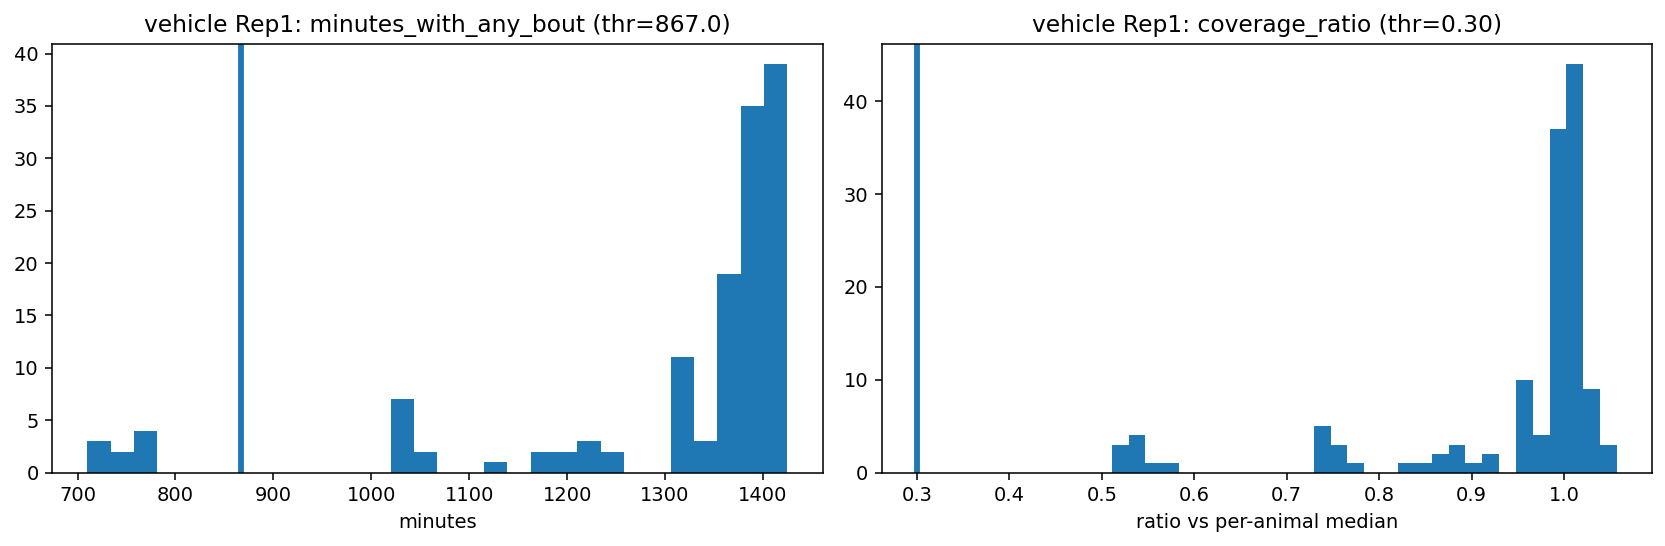

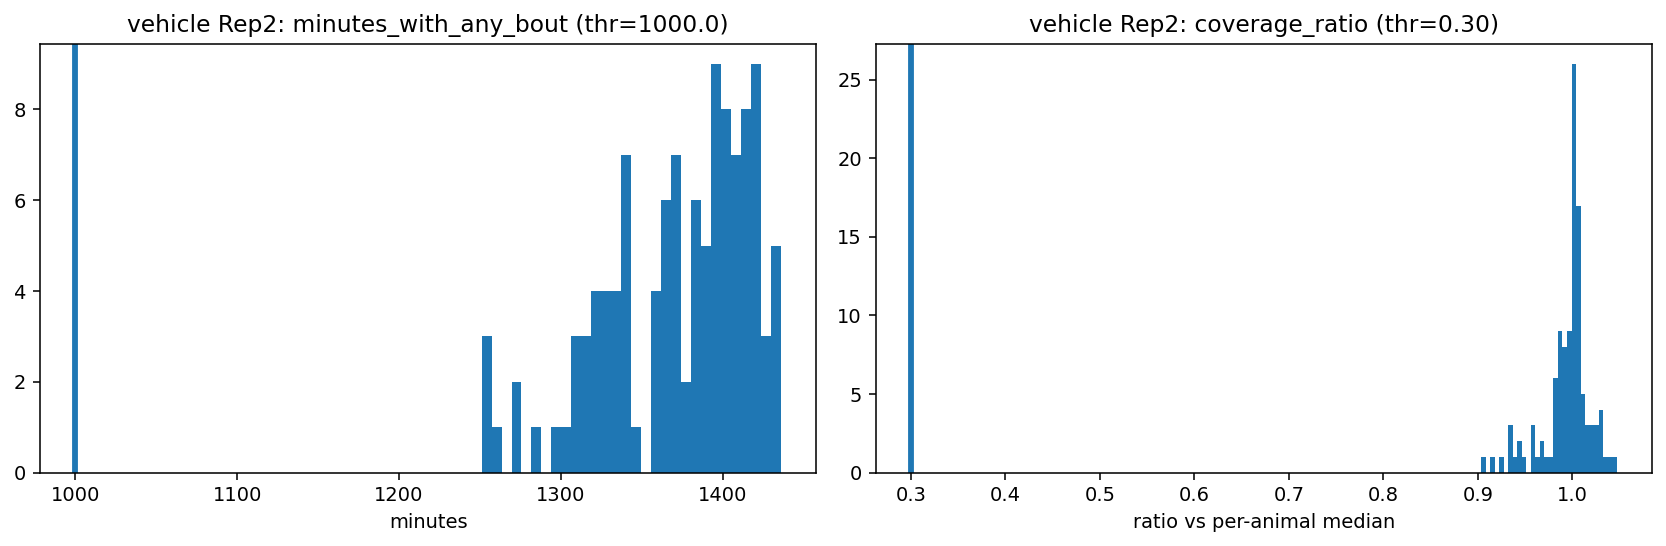

In [29]:

# Visualize coverage distributions + chosen thresholds (per group/rep)
for (group, rep), g in cov_df.groupby(["group","replicate"]):
    rule = qc_rules_df[(qc_rules_df["group"]==group) & (qc_rules_df["replicate"]==rep)].iloc[0]
    thr_m = rule["thr_minutes_any"]
    thr_r = rule["thr_ratio"]

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].hist(g["minutes_with_any_bout"], bins=30)
    axes[0].axvline(thr_m, linewidth=3)
    axes[0].set_title(f"{group} {rep}: minutes_with_any_bout (thr={thr_m:.1f})")
    axes[0].set_xlabel("minutes")

    axes[1].hist(g["coverage_ratio"], bins=30)
    axes[1].axvline(thr_r, linewidth=3)
    axes[1].set_title(f"{group} {rep}: coverage_ratio (thr={thr_r:.2f})")
    axes[1].set_xlabel("ratio vs per-animal median")

    plt.tight_layout()
    plt.show()

---
## 5) Wavelet Features (Ultradian, Circadian, log(U/C))

We compute wavelet features from **locomotion-only** minute counts:
- `U_1_3h`: daily mean ultradian-band power (1–3h)
- `C_23_25h`: daily mean circadian-band power (23–25h)
- `log_U_over_C`: daily mean log ratio

Then we join:
- coverage metrics (`minutes_with_any_bout`, `coverage_ratio`)
- QC keep flag (based on auto thresholds)
- event indicators (`is_event`, `is_event_or_next`)

In [9]:

def compute_wavelet_power(signal_1min, periods_minutes=PERIODS_MINUTES, w=5):
    x = pd.Series(signal_1min).interpolate().bfill().ffill().fillna(0).values
    fs = 1
    scales = periods_minutes * fs * w / (2 * np.pi)
    coeffs = cwt(x, morlet2, scales, w=w)
    power = np.abs(coeffs) ** 2
    return power, periods_minutes

def extract_band_power_ts(power, periods_minutes, band_hours):
    periods_hours = periods_minutes / 60
    mask = (periods_hours >= band_hours[0]) & (periods_hours <= band_hours[1])
    if not np.any(mask):
        return np.zeros(power.shape[1])
    return np.max(power[mask, :], axis=0)

def daily_mean_from_minute_ts(minute_ts, n_days):
    out = []
    for day in range(1, n_days + 1):
        s = (day - 1) * MINUTES_PER_DAY
        e = day * MINUTES_PER_DAY
        out.append(np.nanmean(minute_ts[s:e]) if e <= len(minute_ts) else np.nan)
    return out

def robust_z(x, eps=1e-8):
    x = np.asarray(x, dtype=float)
    med = np.nanmedian(x)
    mad = np.nanmedian(np.abs(x - med))
    return (x - med) / (mad + eps)

print("Wavelet + z-score functions ready.")

Wavelet + z-score functions ready.


In [30]:

# Build wavelet daily features per mouse-day (valid days only)
rows = []

for group, reps in GROUPS.items():
    for rep, cfg in reps.items():
        vstart, vend = cfg["valid_days"]
        n_days = cfg["n_days"]

        # Event day sets
        event_days = {cfg["dose_1_day"], cfg["cage_change_day"], cfg["dose_2_day"]}
        event_and_next = set(event_days) | {d + 1 for d in event_days}

        rep_df = df_bouts[(df_bouts["group"]==group) & (df_bouts["replicate"]==rep)].copy()
        rep_loco = rep_df[rep_df["state_name"]=="animal_bouts.locomotion"].copy()

        animals = sorted(rep_df["animal_id"].unique())

        start_date = pd.to_datetime(cfg["analysis_start"])
        date_list = [(start_date + pd.Timedelta(days=i)).date() for i in range(n_days)]

        for aid in animals:
            a_loco = rep_loco[rep_loco["animal_id"]==aid].copy()
            if len(a_loco) == 0:
                continue
            cage_id = int(a_loco["cage_id"].iloc[0])

            x_1min = bouts_to_minute_counts_calendar(a_loco, cfg["analysis_start"], n_days)

            power, periods = compute_wavelet_power(x_1min, PERIODS_MINUTES, w=5)
            U_ts = extract_band_power_ts(power, periods, (1, 3))
            C_ts = extract_band_power_ts(power, periods, (23, 25))

            U_day = daily_mean_from_minute_ts(U_ts, n_days)
            C_day = daily_mean_from_minute_ts(C_ts, n_days)

            for day in range(1, n_days + 1):
                if not (vstart <= day <= vend):
                    continue
                u = float(U_day[day-1])
                c = float(C_day[day-1])
                ratio = float(np.log((u + 1e-6) / (c + 1e-6)))

                rows.append({
                    "group": group,
                    "replicate": rep,
                    "cage_id": cage_id,
                    "animal_id": int(aid),
                    "day": int(day),
                    "date": str(date_list[day-1]),
                    "U_1_3h": u,
                    "C_23_25h": c,
                    "log_U_over_C": ratio,
                    "is_event": int(day in event_days),
                    "is_event_or_next": int(day in event_and_next),
                })

feat = pd.DataFrame(rows)

# join coverage metrics
feat = feat.merge(
    cov_df[["group","replicate","animal_id","day","minutes_with_any_bout","coverage_ratio"]],
    on=["group","replicate","animal_id","day"],
    how="left"
)

# apply QC keep flag using auto thresholds for each (group,rep)
feat["qc_keep"] = False
for _, r in qc_rules_df.iterrows():
    m = (feat["group"]==r["group"]) & (feat["replicate"]==r["replicate"])
    feat.loc[m, "qc_keep"] = (
        (feat.loc[m, "minutes_with_any_bout"].fillna(0) >= r["thr_minutes_any"]) &
        (feat.loc[m, "coverage_ratio"].fillna(0) >= r["thr_ratio"])
    )

print("Feature rows:", len(feat))
print("QC keep rate by group/rep:")
print(feat.groupby(["group","replicate"])["qc_keep"].mean().round(3))
feat.head()

Feature rows: 252
QC keep rate by group/rep:
group    replicate
vehicle  Rep1         0.933
         Rep2         0.974
Name: qc_keep, dtype: float64


,group,replicate,cage_id,animal_id,day,date,U_1_3h,C_23_25h,log_U_over_C,is_event,is_event_or_next,minutes_with_any_bout,coverage_ratio,qc_keep
0,vehicle,Rep1,4918,9257,2,2025-01-08,88.295163,481.289737,-1.695784,0,0,1323.0,0.963583,True
1,vehicle,Rep1,4918,9257,3,2025-01-09,50.588245,925.629153,-2.906754,0,0,1402.0,1.021122,True
2,vehicle,Rep1,4918,9257,4,2025-01-10,83.272562,1085.039361,-2.567252,0,0,1390.0,1.012382,True
3,vehicle,Rep1,4918,9257,5,2025-01-11,60.680639,1091.819384,-2.889976,0,0,1373.0,1.000000,True
4,vehicle,Rep1,4918,9257,6,2025-01-12,103.568968,1299.889968,-2.529797,0,0,1373.0,1.000000,True


---
## 6) Per-Replicate PCA + Gaussian Mixture + Confound + Monte Carlo

For each (group, replicate), we run:

### (A) Robust within-mouse normalization
Compute `z_U`, `z_C`, `z_log(U/C)` per animal **using QC-kept days only**.

### (B) PCA
Fit PCA on z-features and report:
- explained variance
- loadings

### (C) 2-component Gaussian mixture (GMM) on PCA space
Fit GMM on (PC1, PC2) and get `p_aberrant`.  
We define the “aberrant component” as the one with **lower mean z_U** (suppressed ultradian).

### (D) Handling confound enrichment
Compare `p_aberrant` on event±1 days vs normal days (Mann-Whitney U).

### (E) Monte Carlo cyclicity test (lag=4 days)
Compute mean autocorr@4 for `p_aberrant` per mouse, averaged across mice.  
Generate null distributions by **circularly shifting** each mouse’s series.  
Report a p-value-ish upper-tail probability `P(null ≥ observed)`.  
Repeat after removing event±1 days.

You can control Monte Carlo cost with `N_SIMS`.

In [31]:

def autocorr_lag(x, lag=4):
    x = np.asarray(x, dtype=float)
    if len(x) <= lag:
        return np.nan
    x0, x1 = x[:-lag], x[lag:]
    if np.nanstd(x0) < 1e-10 or np.nanstd(x1) < 1e-10:
        return np.nan
    return np.corrcoef(x0, x1)[0, 1]

def circular_shift(arr, k):
    arr = np.asarray(arr)
    if len(arr) == 0:
        return arr
    k = k % len(arr)
    return np.concatenate([arr[-k:], arr[:-k]]) if k != 0 else arr

def cyclicity_score(df, prob_col="p_aberrant", lag=4):
    vals = []
    for aid, g in df.groupby("animal_id"):
        g = g.sort_values("day")
        vals.append(autocorr_lag(g[prob_col].values, lag=lag))
    vals = np.asarray(vals, dtype=float)
    return float(np.nanmean(vals)), vals

def monte_carlo_null(df, prob_col="p_aberrant", lag=4, n_sims=500, seed=0):
    rng = np.random.default_rng(seed)
    null = []
    for _ in range(n_sims):
        parts = []
        for aid, g in df.groupby("animal_id"):
            g = g.sort_values("day").copy()
            s = g[prob_col].values
            k = rng.integers(0, len(s)) if len(s) > 0 else 0
            g["_shift"] = circular_shift(s, k)
            parts.append(g)
        tmp = pd.concat(parts, ignore_index=True)
        # compute mean ac@lag over mice
        acs = []
        for aid, g2 in tmp.groupby("animal_id"):
            g2 = g2.sort_values("day")
            acs.append(autocorr_lag(g2["_shift"].values, lag=lag))
        null.append(float(np.nanmean(acs)))
    return np.asarray(null, dtype=float)

print("Monte Carlo helpers ready.")

Monte Carlo helpers ready.


In [32]:
def run_full_analysis(feat_all, group, rep, n_sims=500, lag=4, show_plots=True):
    """
    Full per-(group,rep) pipeline:
      - robust within-mouse z-features (QC-kept days only)
      - PCA on z-features (VISUALIZATION ONLY)
      - 2-comp GMM on estrus-relevant space (z_U, z_log(U/C)) -> p_aberrant
      - confound enrichment (event±1 vs normal)
      - Monte Carlo cyclicity test at lag=4 (with + without event±1)
      - safe plotting for NaN/null edge cases
    """

    # ----------------------------
    # Subset to this group/rep + QC-kept days
    # ----------------------------
    sub = feat_all[
        (feat_all["group"] == group) &
        (feat_all["replicate"] == rep) &
        (feat_all["qc_keep"])
    ].copy()

    if len(sub) < 10:
        raise ValueError(f"{group} {rep}: Too few rows after QC_keep (n={len(sub)}).")

    # ----------------------------
    # Robust z per animal (on retained days)
    # ----------------------------
    sub["z_U_1_3h"] = sub.groupby("animal_id")["U_1_3h"].transform(lambda s: robust_z(s.values))
    sub["z_C_23_25h"] = sub.groupby("animal_id")["C_23_25h"].transform(lambda s: robust_z(s.values))
    sub["z_log_U_over_C"] = sub.groupby("animal_id")["log_U_over_C"].transform(lambda s: robust_z(s.values))

    Z = ["z_U_1_3h", "z_C_23_25h", "z_log_U_over_C"]
    sub = sub.dropna(subset=Z).copy()

    if len(sub) < 10:
        raise ValueError(f"{group} {rep}: Too few non-NaN rows after z-feature dropna (n={len(sub)}).")

    # ----------------------------
    # PCA (visualization space)
    # ----------------------------
    pca = PCA(n_components=2, random_state=0)
    PC = pca.fit_transform(sub[Z].values)
    sub["PC1"], sub["PC2"] = PC[:, 0], PC[:, 1]

    evr = pca.explained_variance_ratio_
    loadings = pd.DataFrame(pca.components_.T, index=Z, columns=["PC1", "PC2"])

    # ----------------------------
    # GMM for p_aberrant (FIT ON ESTRUS-RELEVANT FEATURES, NOT PCs)
    # ----------------------------
    Xg = sub[["z_U_1_3h", "z_log_U_over_C"]].values

    gmm = GaussianMixture(
        n_components=2,
        covariance_type="full",
        reg_covar=1e-6,
        random_state=0
    )
    gmm.fit(Xg)
    post = gmm.predict_proba(Xg)
    hard = gmm.predict(Xg)
    weights = gmm.weights_

    # aberrant = component with LOWER mean z_U (suppressed ultradian)
    mean_zU_by_comp = [sub.loc[hard == k, "z_U_1_3h"].mean() for k in [0, 1]]
    aberr_comp = int(np.argmin(mean_zU_by_comp))
    sub["p_aberrant"] = post[:, aberr_comp]

    # ----------------------------
    # Confound enrichment: event±1 vs normal
    # ----------------------------
    ev = sub.loc[sub["is_event_or_next"] == 1, "p_aberrant"].values
    ne = sub.loc[sub["is_event_or_next"] == 0, "p_aberrant"].values

    if len(ev) > 0 and len(ne) > 0 and np.isfinite(ev).any() and np.isfinite(ne).any():
        p_mwu = float(mannwhitneyu(ev, ne, alternative="greater").pvalue)
        mean_ev, mean_ne = float(np.nanmean(ev)), float(np.nanmean(ne))
    else:
        p_mwu, mean_ev, mean_ne = np.nan, np.nan, np.nan

    # ----------------------------
    # Monte Carlo cyclicity (all days)
    # ----------------------------
    obs_ac, _ = cyclicity_score(sub, prob_col="p_aberrant", lag=lag)
    null = monte_carlo_null(sub, prob_col="p_aberrant", lag=lag, n_sims=n_sims, seed=0)
    null_f = null[np.isfinite(null)]
    p_mc = float((np.sum(null_f >= obs_ac) + 1) / (len(null_f) + 1)) if len(null_f) > 0 else np.nan

    # ----------------------------
    # Monte Carlo cyclicity (no event±1)
    # ----------------------------
    sub_noevt = sub[sub["is_event_or_next"] == 0].copy()
    obs_ac_noevt, _ = cyclicity_score(sub_noevt, prob_col="p_aberrant", lag=lag)

    if len(sub_noevt) > 0:
        null_noevt = monte_carlo_null(sub_noevt, prob_col="p_aberrant", lag=lag, n_sims=n_sims, seed=1)
        null_noevt_f = null_noevt[np.isfinite(null_noevt)]
        p_mc_noevt = float((np.sum(null_noevt_f >= obs_ac_noevt) + 1) / (len(null_noevt_f) + 1)) if len(null_noevt_f) > 0 else np.nan
    else:
        null_noevt_f = np.array([])
        p_mc_noevt = np.nan

    # ----------------------------
    # Outliers in PCA space (for QC/debug)
    # ----------------------------
    sub["pc_r2"] = sub["PC1"] ** 2 + sub["PC2"] ** 2
    outliers = sub.sort_values("pc_r2", ascending=False).head(8)[
        ["group", "replicate", "cage_id", "animal_id", "day", "date", "PC1", "PC2",
         "U_1_3h", "C_23_25h", "log_U_over_C",
         "z_U_1_3h", "z_C_23_25h", "z_log_U_over_C",
         "minutes_with_any_bout", "coverage_ratio", "is_event_or_next", "p_aberrant"]
    ]

    # ----------------------------
    # Plots (optional)
    # ----------------------------
    if show_plots:
        # PCA colored by event±1
        plt.figure(figsize=(7, 5))
        m = sub["is_event_or_next"].astype(bool)
        plt.scatter(sub.loc[~m, "PC1"], sub.loc[~m, "PC2"], alpha=0.55, s=18, label="normal")
        plt.scatter(sub.loc[m, "PC1"], sub.loc[m, "PC2"], alpha=0.85, s=20, label="event±1")
        plt.xlabel("PC1"); plt.ylabel("PC2")
        plt.title(f"{group} {rep}: PCA after auto-QC (n={len(sub)})")
        plt.legend(); plt.tight_layout(); plt.show()

        # PCA colored by p_aberrant
        plt.figure(figsize=(7, 5))
        sc = plt.scatter(sub["PC1"], sub["PC2"], c=sub["p_aberrant"], s=18, alpha=0.85)
        plt.xlabel("PC1"); plt.ylabel("PC2")
        plt.title(f"{group} {rep}: PCA colored by p_aberrant (GMM on z_U + z_log(U/C))")
        plt.colorbar(sc, label="p_aberrant"); plt.tight_layout(); plt.show()

        # Monte Carlo hist (all days)
        if len(null_f) > 0:
            plt.figure(figsize=(7, 4))
            plt.hist(null_f, bins=30)
            if np.isfinite(obs_ac):
                plt.axvline(obs_ac, linewidth=3)
            plt.xlabel(f"mean autocorr@{lag} (null)"); plt.ylabel("count")
            plt.title(f"{group} {rep}: Monte Carlo (p≈{p_mc:.3g})")
            plt.tight_layout(); plt.show()

        # Monte Carlo hist (no events)
        if len(null_noevt_f) > 0:
            plt.figure(figsize=(7, 4))
            plt.hist(null_noevt_f, bins=30)
            if np.isfinite(obs_ac_noevt):
                plt.axvline(obs_ac_noevt, linewidth=3)
            plt.xlabel(f"mean autocorr@{lag} (null, no events)"); plt.ylabel("count")
            plt.title(f"{group} {rep}: Monte Carlo no-events (p≈{p_mc_noevt:.3g})")
            plt.tight_layout(); plt.show()
        else:
            print(f"{group} {rep}: Skipping no-events histogram (null_noevt all NaN / insufficient data)")

        print(f"{group} {rep}: GMM weights={weights}, aberr_comp={aberr_comp}, mean_zU_by_comp={mean_zU_by_comp}")
        print(f"{group} {rep}: p_aberrant >0.9 frac={(sub['p_aberrant']>0.9).mean():.3f}, <0.1 frac={(sub['p_aberrant']<0.1).mean():.3f}")

    summary = {
        "group": group,
        "replicate": rep,
        "n_rows_qc": int(len(sub)),
        "evr_pc1": float(evr[0]),
        "evr_pc2": float(evr[1]),
        "evr_cum": float(np.sum(evr)),
        "loadings": loadings.round(4).to_string(),

        "gmm_weights_comp0": float(weights[0]),
        "gmm_weights_comp1": float(weights[1]),
        "gmm_mean_zU_comp0": float(mean_zU_by_comp[0]),
        "gmm_mean_zU_comp1": float(mean_zU_by_comp[1]),
        "aberr_comp": int(aberr_comp),

        "mean_p_aberrant_event±1": mean_ev,
        "mean_p_aberrant_normal": mean_ne,
        "mwu_p_event_greater": p_mwu,

        "obs_mean_autocorr@4": float(obs_ac),
        "mc_pvalue": p_mc,

        "obs_mean_autocorr@4_noevents": float(obs_ac_noevt),
        "mc_pvalue_noevents": p_mc_noevt,
    }

    return sub, summary, outliers

---
## 7) Run the Full Pipeline (per group × replicate)

Tune these:
- `N_SIMS`: Monte Carlo simulations (start at 200–500; increase for final figures)
- `SHOW_PLOTS`: True/False

Outputs:
- `summary_df`: one row per (group,rep)
- `outliers_df`: outlier mouse-days across runs

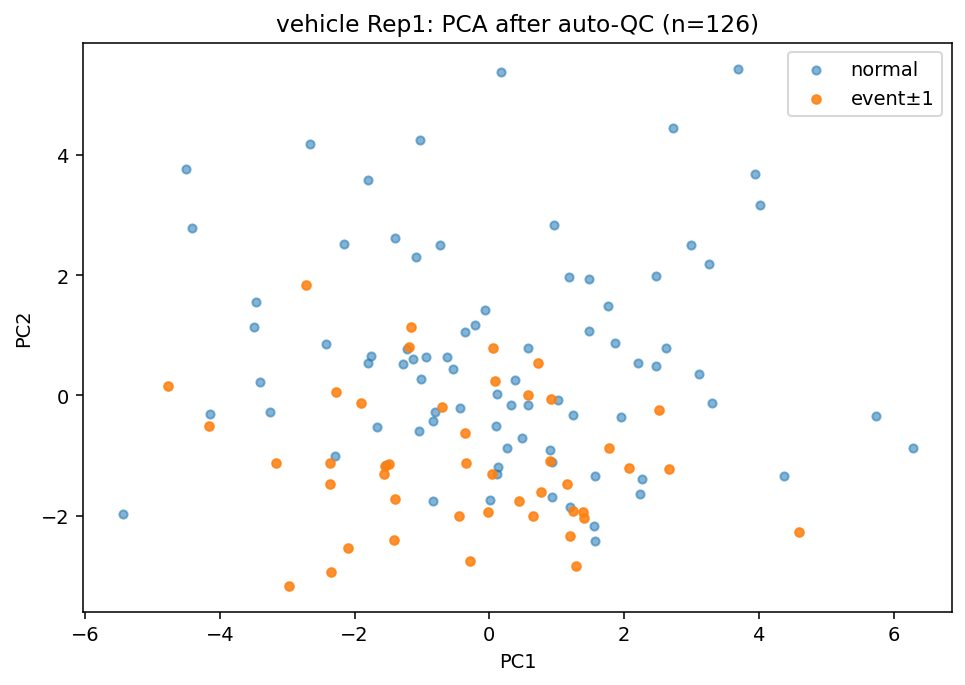

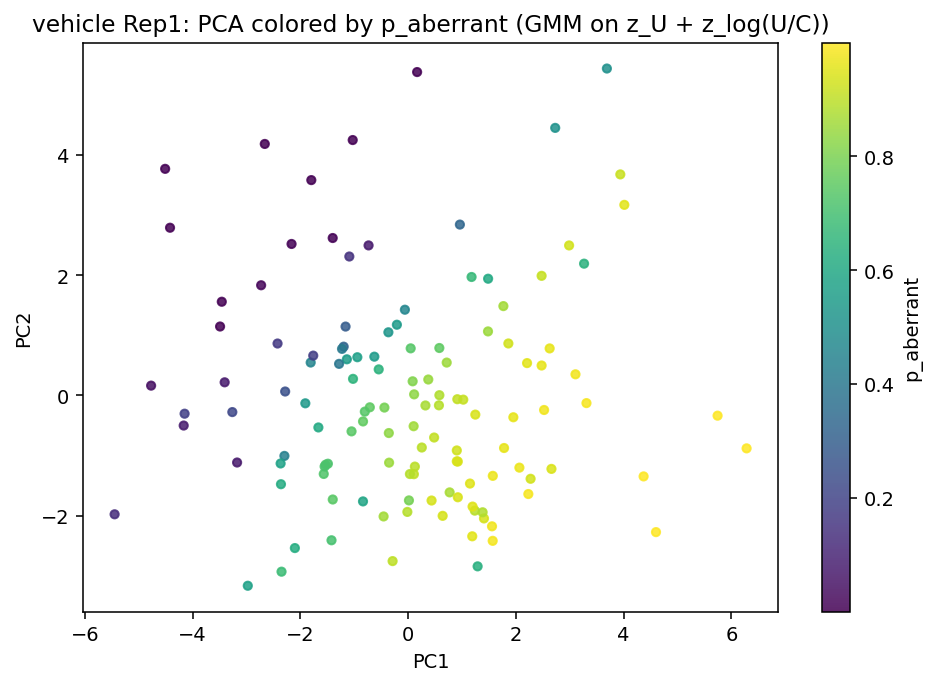

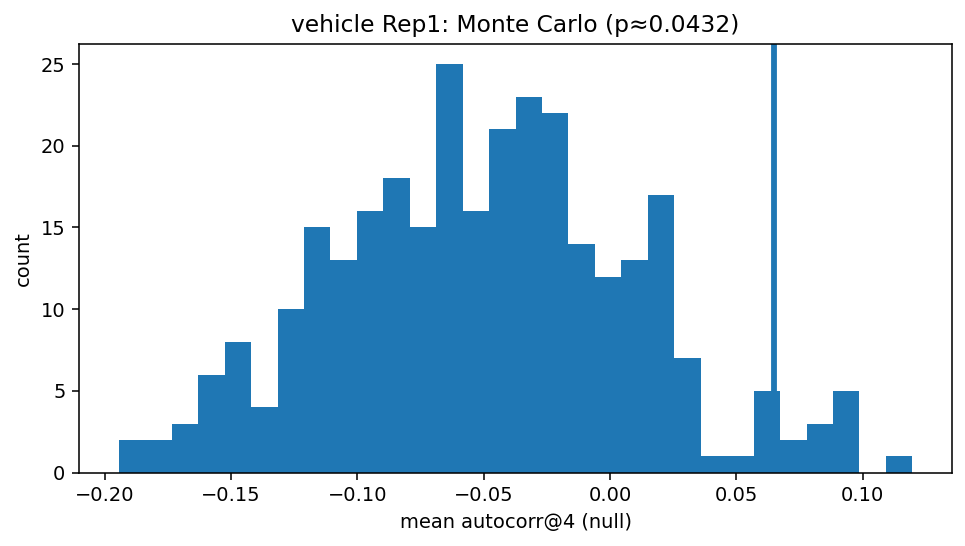

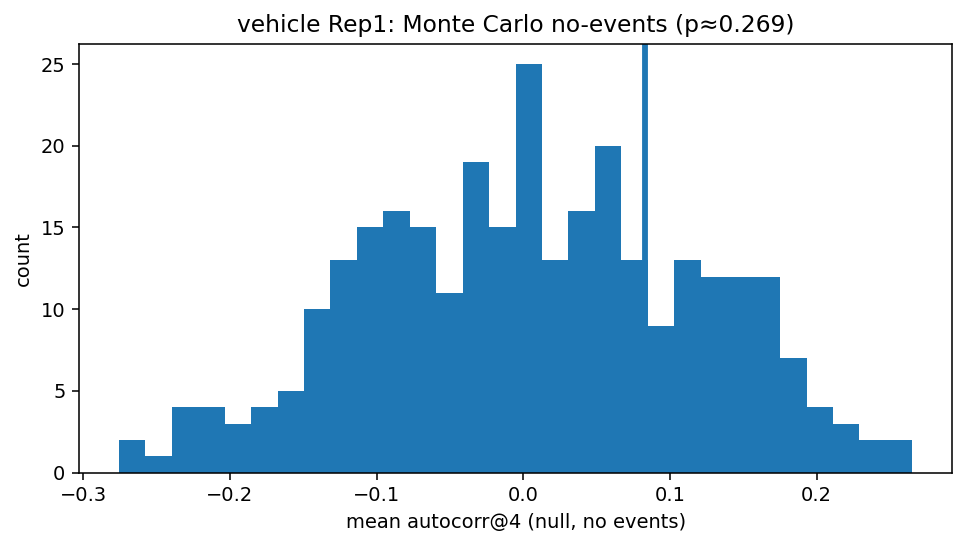

vehicle Rep1: GMM weights=[0.65112189 0.34887811], aberr_comp=0, mean_zU_by_comp=[-0.5366708874278369, 2.321601288295273]
vehicle Rep1: p_aberrant >0.9 frac=0.310, <0.1 frac=0.127


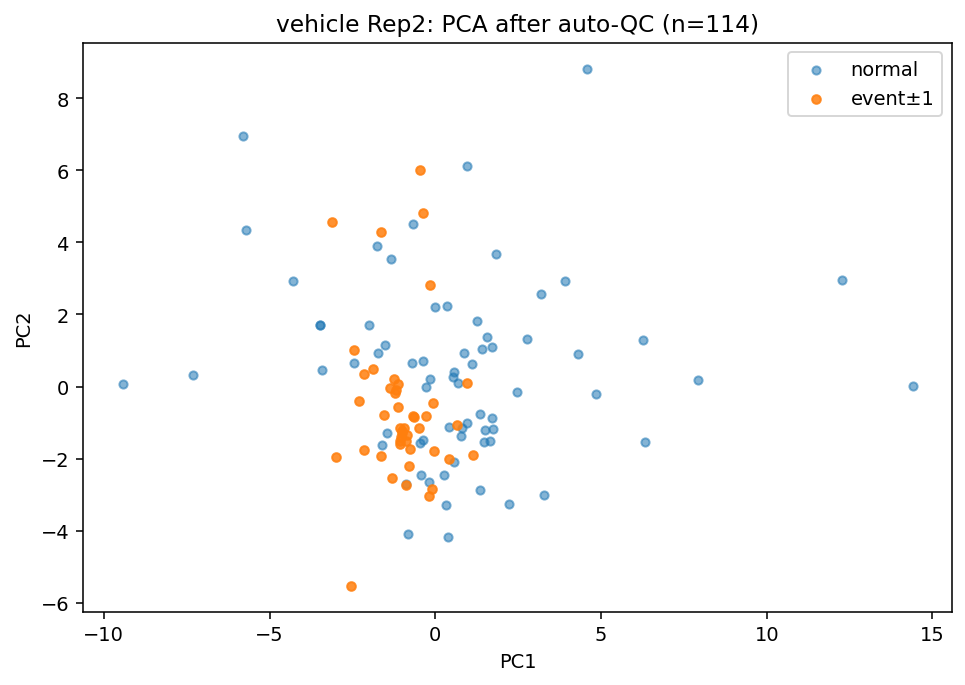

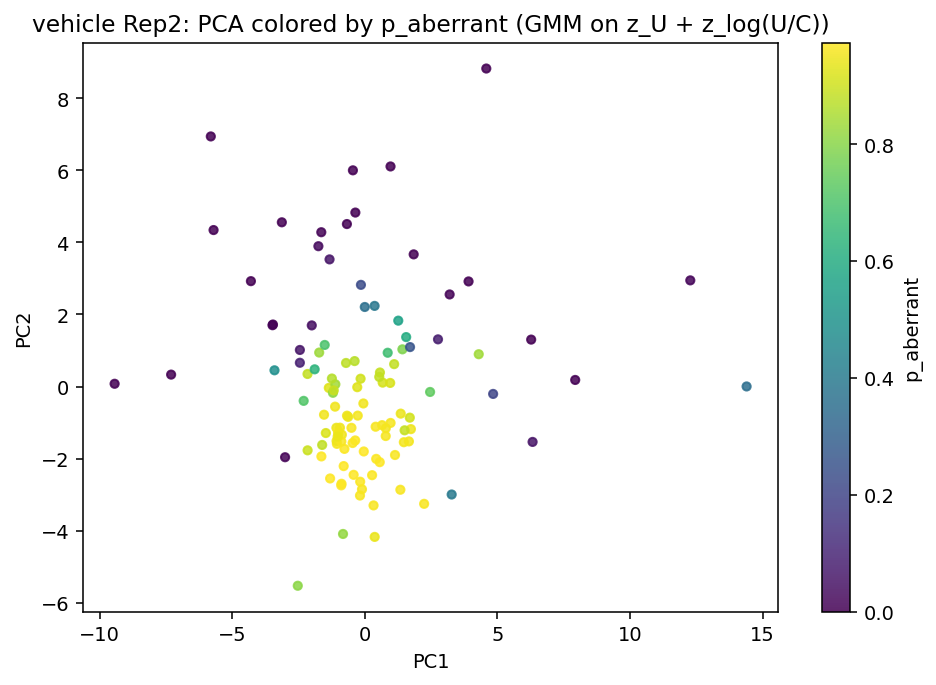

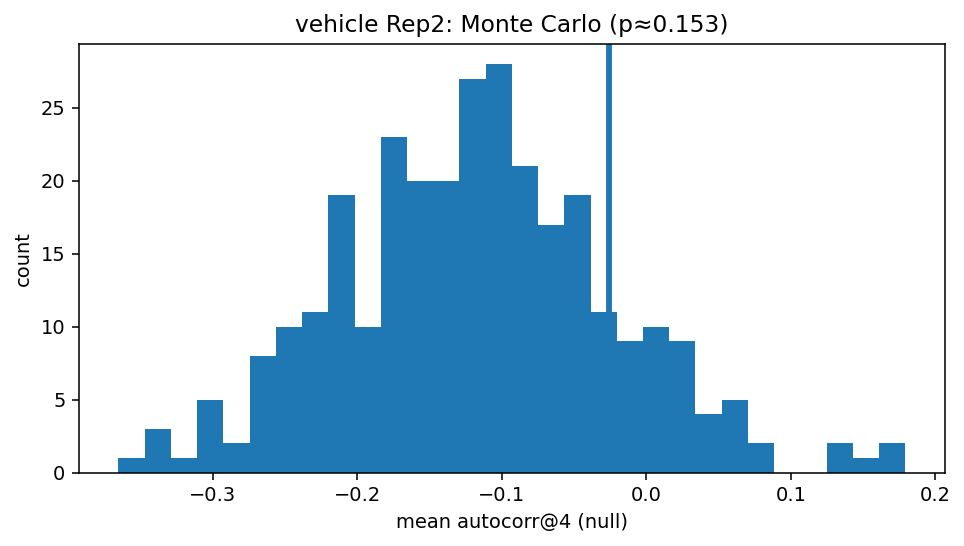

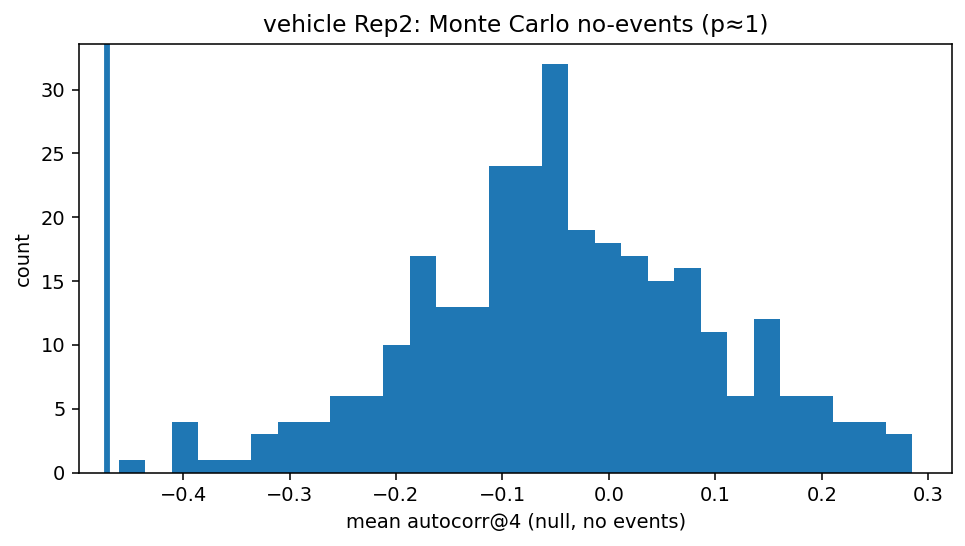

vehicle Rep2: GMM weights=[0.3475423 0.6524577], aberr_comp=1, mean_zU_by_comp=[2.1571985065861052, -0.29887447421849833]
vehicle Rep2: p_aberrant >0.9 frac=0.465, <0.1 frac=0.246


,group,replicate,n_rows_qc,evr_pc1,evr_pc2,evr_cum,loadings,gmm_weights_comp0,gmm_weights_comp1,gmm_mean_zU_comp0,gmm_mean_zU_comp1,aberr_comp,mean_p_aberrant_event±1,mean_p_aberrant_normal,mwu_p_event_greater,obs_mean_autocorr@4,mc_pvalue,obs_mean_autocorr@4_noevents,mc_pvalue_noevents
0,vehicle,Rep1,126,0.571845,0.386497,0.958342,PC1 PC2\nz_U_1_3h ...,0.651122,0.348878,-0.536671,2.321601,0,0.715033,0.624395,0.182395,0.064901,0.043189,0.082790,0.269103
1,vehicle,Rep2,114,0.564883,0.363868,0.928751,PC1 PC2\nz_U_1_3h ...,0.347542,0.652458,2.157199,-0.298874,1,0.785861,0.556025,0.000660,-0.025744,0.152824,-0.471086,1.000000


In [33]:
N_SIMS = 300
LAG = 4

summaries = []
outlier_tables = []
results_by_run = {}

for group in GROUPS.keys():
    for rep in ["Rep1","Rep2"]:
        sub, summary, outliers = run_full_analysis(
            feat, group, rep, n_sims=N_SIMS, lag=LAG, show_plots=SHOW_PLOTS
        )
        summaries.append(summary)
        outlier_tables.append(outliers.assign(run=f"{group}|{rep}"))
        results_by_run[(group,rep)] = sub

summary_df = pd.DataFrame(summaries)
outliers_df = pd.concat(outlier_tables, ignore_index=True)

summary_df

---
## 8) Final Copy-Paste Summary Cell

This cell prints:
- Auto-QC thresholds per (group,rep) + how they were chosen
- Final pipeline summary table (PCA + GMM + confound + Monte Carlo)
- Outliers table

It also saves CSVs:
- `auto_qc_rules.csv`
- `wavelet_pipeline_summary.csv`
- `wavelet_pipeline_outliers.csv`

In [34]:

# =============================================================================
# FINAL SUMMARY (copy/paste friendly)
# =============================================================================
print("="*110)
print("AUTO-QC RULES (per group/rep)")
print("="*110)
qc_display = qc_rules_df.copy()
qc_display["info_minutes"] = qc_display["info_minutes"].apply(lambda d: str(d))
qc_display["info_ratio"] = qc_display["info_ratio"].apply(lambda d: str(d))
print(qc_display[["group","replicate","thr_minutes_any","thr_ratio","info_minutes","info_ratio","n_rows"]].to_string(index=False))

print("\n" + "="*110)
print("PIPELINE SUMMARY (per group/rep)")
print("="*110)
cols = [
    "group","replicate","n_rows_qc",
    "evr_pc1","evr_pc2","evr_cum",
    "aberr_comp",
    "mean_p_aberrant_event±1","mean_p_aberrant_normal","mwu_p_event_greater",
    "obs_mean_autocorr@4","mc_pvalue",
    "obs_mean_autocorr@4_noevents","mc_pvalue_noevents"
]
print(summary_df[cols].round(4).to_string(index=False))

print("\n" + "="*110)
print("PCA LOADINGS (per group/rep)")
print("="*110)
for _, row in summary_df.iterrows():
    print("\n" + "-"*110)
    print(f"{row['group']} {row['replicate']}  |  EVR: [{row['evr_pc1']:.4f}, {row['evr_pc2']:.4f}] (cum={row['evr_cum']:.4f})")
    print(row["loadings"])

print("\n" + "="*110)
print("TOP OUTLIERS (per run)")
print("="*110)
print(outliers_df.to_string(index=False))

# Save CSVs
qc_rules_df.to_csv("auto_qc_rules.csv", index=False)
summary_df.to_csv("wavelet_pipeline_summary.csv", index=False)
outliers_df.to_csv("wavelet_pipeline_outliers.csv", index=False)

print("\nSaved: auto_qc_rules.csv, wavelet_pipeline_summary.csv, wavelet_pipeline_outliers.csv")

AUTO-QC RULES (per group/rep)
  group replicate  thr_minutes_any  thr_ratio                                                                                                                                                       info_minutes                                         info_ratio  n_rows
vehicle      Rep1       866.975613        0.3 {'bic1': -88.32086702746203, 'bic2': -215.67642598570578, 'bic_delta': 127.35555895824375, 'n': 135, 'method': 'gmm2', 'low_comp': 0, 'thr_log': 6.76616361843805} {'method': 'fixed_conservative', 'thr_ratio': 0.3}     135
vehicle      Rep2      1000.000000        0.3    {'bic1': -442.477032842684, 'bic2': -457.4584568275416, 'bic_delta': 14.9814239848576, 'n': 114, 'method': 'gmm2', 'low_comp': 1, 'thr_log': 7.222535984251935} {'method': 'fixed_conservative', 'thr_ratio': 0.3}     114

PIPELINE SUMMARY (per group/rep)
  group replicate  n_rows_qc  evr_pc1  evr_pc2  evr_cum  aberr_comp  mean_p_aberrant_event±1  mean_p_aberrant_normal  mwu_p_event_gr

In [18]:
# Diagnose GMM components
weights = gmm.weights_
print("GMM weights:", weights)

for k in [0, 1]:
    idx = (hard == k)
    print(f"\nComponent {k}: n={idx.sum()}  weight≈{weights[k]:.3f}")
    print("  mean z_U:", sub.loc[idx, "z_U_1_3h"].mean())
    print("  mean z_C:", sub.loc[idx, "z_C_23_25h"].mean())
    print("  mean z_log(U/C):", sub.loc[idx, "z_log_U_over_C"].mean())

# How binary are the posteriors?
print("\nPosterior summary (current p_aberrant):")
print(sub["p_aberrant"].describe())
print("Fraction > 0.9:", (sub["p_aberrant"] > 0.9).mean())
print("Fraction < 0.1:", (sub["p_aberrant"] < 0.1).mean())

NameError: name 'gmm' is not defined

In [19]:
[name for name in globals() if name.lower().startswith("gmm")]

['gmm_boundary_threshold']

In [20]:
[name for name in globals() if "gmm" in name.lower()]

['gmm_boundary_threshold']

In [21]:
print("GMM weights:", gmm.weights_)
print("mean z_U by comp:", [sub.loc[hard==k, "z_U_1_3h"].mean() for k in [0,1]])

NameError: name 'gmm' is not defined